# Steven Tran - Machine Learning Midterm

# Verify key exists

In [229]:
import json

# The big secrete MongoDB key
with open('C:\\Users\\aznma\\Documents\\Github Projects\\DATA320\\credentials.json') as credentials:
    data = json.load(credentials)
    secret_key = data['mongodb']

print(f"My secret key is {len(secret_key)} characters in length.")

My secret key is 73 characters in length.


# Connect to MongoDB & init collections

In [230]:
import pymongo
import certifi
import pandas as pd
import re

# Connect to db and verify connection
client = pymongo.MongoClient(secret_key, tlsCAFile=certifi.where())
print(f"Using MongoDB version {client.server_info()['version']}.")

db = client.data320
YEAR = 2003 # cuz I was born '03

all_collections = db.list_collection_names()
print(f"Collections in 'data320' database: {all_collections}")

# IMDB 2003 data
imdb_view = pd.DataFrame(db.IMDB_Pipeline_View.find({"release_year": YEAR}, {"_id": 0}))

# Metacritic 2003 data
metacritic_view = pd.DataFrame(db.metacritic.find({"release_date": re.compile(f"{YEAR}")}, {"_id": 0}))

# Metacritic view conversion
metacritic_view.score = pd.to_numeric(metacritic_view.score, errors='coerce')
metacritic_view.release_date = pd.to_datetime(metacritic_view.release_date, errors='coerce')


Using MongoDB version 8.0.16.
Collections in 'data320' database: ['IMDB', 'metacritic', 'IMDB_Pipeline_View']


# Merge collections & drop curr NaN values

In [231]:
# Merge IMDB and Metacritic data using inner join on title
merged_view = pd.merge(imdb_view, metacritic_view, how="inner", on="title")

# Clean merged data by dropping rows with missing values in key columns (address ValueError: zero-size array to reduction operation maximum which has no identity)
merged_view_clean = merged_view.dropna(subset=['gross_sales_usd', 'user_rating', 'budget_usd', 'opening_weekend_usd', 'votes', 'runtime']).copy()
merged_view_clean.head()

,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,producer,...,opening_weekend_usd,budget_first,is_budget_first_usd,budget_value,budget_usd,movie_id,release_date_y,description,score,thumbnail
1,"$90,000,000 (estimated)","Eddie Murphy, Terence Stamp, Nathaniel Parker,...",PG,"Walt Disney Pictures, Gunn Films, Doom Buggy P...",Rob Minkoff,"Comedy, Family, Fantasy, Horror, Mystery","$182,290,266",338094,"$24,278,410, 30 Nov 2003","Barry Bernardi, Andrew Gunn, Don Hahn, Rob Min...",...,24278410,"$90,000,000",True,"{'match': '90,000,000', 'idx': 1, 'captures': ...",90000000,12778,2003-11-26,The Haunted Mansion comes alive like never bef...,34,https://static.metacritic.com/images/products/...
2,"$140,000,000 (estimated)","Johnny Depp, Geoffrey Rush, Orlando Bloom, Kei...",PG-13,"Walt Disney Pictures, Jerry Bruckheimer Films",Gore Verbinski,"Action, Adventure, Fantasy","$654,264,015, 11 Jan 2012",325980,"$46,630,690, 13 Jul 2003","Jerry Bruckheimer, Paul Deason, Bruce Hendrick...",...,46630690,"$140,000,000",True,"{'match': '140,000,000', 'idx': 1, 'captures':...",140000000,12569,2003-07-09,For the roguish yet charming Captain Jack Spar...,63,https://static.metacritic.com/images/products/...
4,"$30,000,000 (estimated)","Uma Thurman, Lucy Liu, Vivica A. Fox, Daryl Ha...","R, TV-14, TV-MA","Miramax, A Band Apart, Super Cool ManChu, Shaw...",Quentin Tarantino,"Action, Crime, Drama, Thriller","$180,949,045, 28 May 2012",266697,"$22,089,322, 12 Oct 2003","Lawrence Bender, Mitsuhisa Ishikawa, Koko Maed...",...,22089322,"$30,000,000",True,"{'match': '30,000,000', 'idx': 1, 'captures': ...",30000000,12518,2003-10-10,An epic tale of one woman's quest for justice ...,69,https://static.metacritic.com/images/products/...
5,"$7,000,000 (estimated)","Chad Bannon, William Bassett, Karen Black, Eri...","TV-MA::(cable rating), R","Spectacle Entertainment Group, Universal Pictures",Rob Zombie,Horror,"$4,194,583",251736,"$3,460,666, 13 Apr 2003","Andy Given, Andy Gould, Joel Hatch, Robert K. ...",...,3460666,"$7,000,000",True,"{'match': '7,000,000', 'idx': 1, 'captures': [...",7000000,12793,2003-04-11,Two young couples take a misguided tour onto t...,31,https://static.metacritic.com/images/products/...
8,"$4,500,000 (estimated)","Charlize Theron, Christina Ricci, Bruce Dern, ...",R,"Media 8 Entertainment, Newmarket Films, DEJ Pr...",Patty Jenkins,"Biography, Crime, Drama, Thriller","$64,240,813",340855,"$86,831, 28 Dec 2003","David Alvarado, Mark Damon, Andreas Grosch, St...",...,86831,"$4,500,000",True,"{'match': '4,500,000', 'idx': 1, 'captures': [...",4500000,12472,2003-12-24,"In a revelatory performance, Charlize Theron s...",74,https://static.metacritic.com/images/products/...


# Convert data accordingly & run regression analysis

In [232]:
# print(merged_view_clean.isnull().sum()) # debugging line to check for nulls
import re
import pandas as pd
import statsmodels.formula.api as smf

df = merged_view_clean.copy()

# Cleaning functions
ZW_CHARS = r"[\u200b\u200c\u200d\u200e\u2060\uFEFF]" # ty chatgpt

def clean_money(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    s = s.str.replace(ZW_CHARS, "", regex=True) # remove zero-width
    s = s.str.replace(r"[,$]", "", regex=True) # strip commas and $
    s = s.str.replace(r"\s+", "", regex=True) # strip spaces
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True) # keep only digits
    return pd.to_numeric(s, errors="coerce")

def clean_numeric(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    s = s.str.replace(ZW_CHARS, "", regex=True)
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.extract(r"(-?\d+(?:\.\d+)?)", expand=False) # first numeric
    return pd.to_numeric(s, errors="coerce")

def clean_runtime_mins(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    s = s.str.replace(ZW_CHARS, "", regex=True)

    m1 = s.str.extract(r"(\d+)\s*min", expand=False, flags=re.I)
    m2 = s.str.extract(r"PT(\d+)M", expand=False)
    m3 = s.str.extract(r"(\d+)", expand=False)

    out = m1.fillna(m2).fillna(m3)
    return pd.to_numeric(out, errors="coerce")

# Creates new cols with _num suffix
money_cols = ["gross_sales_usd","budget_usd","opening_weekend_usd"]
integer_cols = ["votes"] # 123,456
float_cols = ["user_rating"] # 7.8
runtime_cols = ["runtime"]

for c in money_cols:
    if c in df:
        df[c + "_num"] = clean_money(df[c])

for c in integer_cols:
    if c in df:
        df[c + "_num"] = clean_numeric(df[c])

for c in float_cols:
    if c in df:
        df[c + "_num"] = clean_numeric(df[c])

for c in runtime_cols:
    if c in df:
        df[c + "_num"] = clean_runtime_mins(df[c])

num_cols = ["gross_sales_usd_num","user_rating_num","budget_usd_num",
          "opening_weekend_usd_num","votes_num","runtime_num"]
present = [c for c in num_cols if c in df.columns]
predictors = [c for c in present if c != "gross_sales_usd_num"]
df_model = df[["gross_sales_usd_num"] + predictors]

# Build OLS model
ols_model = smf.ols(formula="gross_sales_usd_num ~ user_rating_num + budget_usd_num + opening_weekend_usd_num + votes_num + runtime_num", data=df_model).fit()
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     gross_sales_usd_num   R-squared:                       0.745
Model:                             OLS   Adj. R-squared:                  0.728
Method:                  Least Squares   F-statistic:                     45.48
Date:                 Wed, 12 Nov 2025   Prob (F-statistic):           9.50e-22
Time:                         18:23:46   Log-Likelihood:                -1647.6
No. Observations:                   84   AIC:                             3307.
Df Residuals:                       78   BIC:                             3322.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

C:\Users\aznma\AppData\Local\Temp\ipykernel_2156\355689845.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out = m1.fillna(m2).fillna(m3)


# Gross Sales vs Opening Weekend Scatter Plot

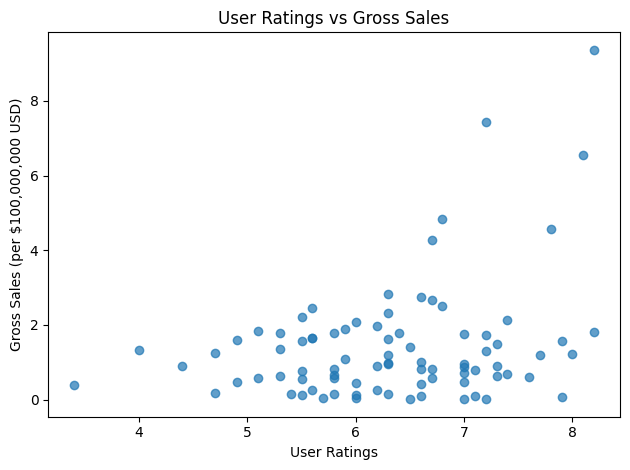

In [233]:
from matplotlib import pyplot as plt

tmp = df_model[["user_rating_num","gross_sales_usd_num"]]
plt.figure()
plt.scatter(tmp["user_rating_num"], tmp["gross_sales_usd_num"] / 100_000_000, alpha=0.7)
plt.title("User Ratings vs Gross Sales")
plt.xlabel("User Ratings")
plt.ylabel("Gross Sales (per $100,000,000 USD)")
plt.tight_layout()
plt.show()

# Distribution of IMDB User Ratings

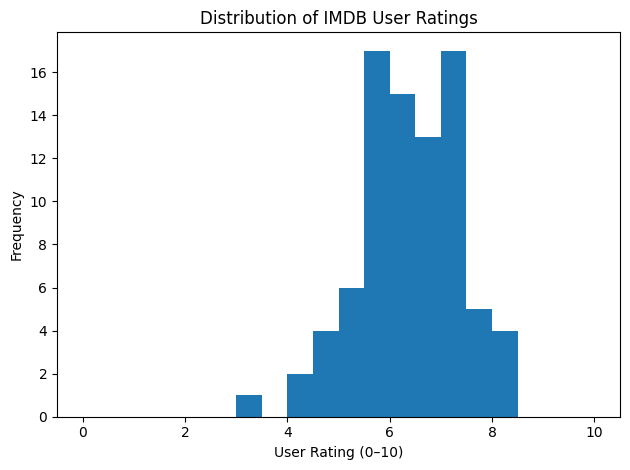

In [234]:
import numpy as np

vals = df_model["user_rating_num"].dropna()
plt.figure()
plt.hist(vals, bins=np.arange(0, 10.5, 0.5))
plt.title("Distribution of IMDB User Ratings")
plt.xlabel("User Rating (0–10)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Conclusions
My scatterplot reveals that user ratings and gross sales have correlation as the higher the user ratings, the higher the gross sales. Now, causation does not equal correlation. However, in this case we can easily
justify that correlation exists as people are more likely to buy movie tickets for X movie if the ratings are higher. Additionally, running a scatterplot of user ratings and opening weekend sales has a somewhat similar 
result which further supports the claim that user ratings = popularity = more sales. On the other hand, the histogram doesn't reveal much other than we see a developing normal distribution. I imagine if there were 
more samples it would be much more bell-curved.


### AI/ML
Was unable to run. PC not strong enough ;-;